# EDA & Bottleneck Analysis - Final RAG Benchmark

Notebook này đọc trực tiếp toàn bộ log dùng trong `benchmark_final.md`, chuẩn hóa dữ liệu theo từng câu hỏi, trực quan hóa hiệu năng và phân tích:

- Chất lượng retrieval và chất lượng câu trả lời
- Latency, token usage, route và partial response
- Hiệu năng theo **8 loại câu hỏi CRAG**
- Bottleneck, nguyên nhân khả dĩ, mức độ ưu tiên và hướng cải thiện

**Phạm vi:** 1.005 câu hỏi từ toàn bộ bộ benchmark cuối. Tất cả log được gộp thành một kết quả đại diện cho cả nhóm; cột nguồn dữ liệu chỉ được giữ để truy vết khi cần audit, không dùng để so sánh từng người/nhóm chạy.

> Lưu ý: các log có thể dùng relevance/RAGAS backend khác nhau. Các kết luận EDA bên dưới tập trung vào hành vi tổng thể và khác biệt theo loại câu hỏi.


In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
try:
    from IPython.display import display, Markdown
except ImportError:
    def display(*args, **kwargs):
        for arg in args:
            print(arg)
    class Markdown(str):
        pass

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5.5)

BASE = Path.cwd()
if not (BASE / "per_question_Hung.jsonl").exists():
    candidate = BASE / "evaluation" / "eval_final"
    if candidate.exists():
        BASE = candidate
assert (BASE / "per_question_Hung.jsonl").exists(), f"Không tìm thấy log trong {BASE}"
print("Log directory:", BASE.resolve())


Log directory: D:\porjects\internship\TeamHN-RAG-Agent\evaluation\eval_final


## 1. Đọc và chuẩn hóa dữ liệu

In [2]:
RETRIEVAL = ["hit@5", "precision@5", "recall@5", "mrr@5", "map@5", "ndcg@5"]
RAGAS = [
    "ragas_faithfulness", "ragas_answer_relevancy", "ragas_answer_correctness",
    "ragas_semantic_similarity", "ragas_context_precision", "ragas_context_recall",
    "ragas_context_entity_recall", "ragas_noise_sensitivity",
]
QUESTION_TYPE_ORDER = [
    "Simple", "Simple w. condition", "Set", "Comparison", "Aggregation",
    "Multi-hop", "Post-processing heavy", "False premise",
]


def normalize_question_type(value):
    text = str(value or "").strip().lower().replace("_", " ")
    text = " ".join(text.split())
    aliases = {
        "simple": "Simple",
        "simple w. condition": "Simple w. condition",
        "simple with condition": "Simple w. condition",
        "set": "Set",
        "comparison": "Comparison",
        "aggregation": "Aggregation",
        "multi-hop": "Multi-hop",
        "multi hop": "Multi-hop",
        "post-processing": "Post-processing heavy",
        "post processing": "Post-processing heavy",
        "post-processing heavy": "Post-processing heavy",
        "post processing heavy": "Post-processing heavy",
        "false premise": "False premise",
    }
    return aliases.get(text, "")


def internal_tags(raw):
    tags = set()
    for part in str(raw or "").split(";"):
        tag = part.strip().split(" ", 1)[0].strip().lower()
        if tag:
            tags.add(tag)
    return tags


def classify_from_internal(q):
    qtypes = str(q.get("question_types", "") or "")
    if not qtypes.strip():
        return ""
    tags = internal_tags(qtypes)
    answerability = str(q.get("answerability", "") or "").strip().lower()
    text = str(q.get("question", "") or "").lower()
    if "unanswerable" in tags or "false_premise" in tags or answerability in {"unanswerable", "false_premise"}:
        return "False premise"
    if "multi_hop" in tags:
        return "Multi-hop"
    if "calculation" in tags:
        if any(m in text for m in ["bao nhiêu", "số lượng", "tổng", "trung bình", "tỷ lệ", "tỉ lệ", "đếm"]):
            return "Aggregation"
        return "Post-processing heavy"
    if "comparison" in tags:
        return "Comparison"
    if "list" in tags:
        return "Set"
    if "condition" in tags or "table_lookup" in tags or "clarification_needed" in tags:
        return "Simple w. condition"
    return "Simple"


def classify_hung(q):
    mapped = classify_from_internal(q)
    if mapped:
        return mapped
    question = str(q.get("question", "") or "").lower()
    expected = str(q.get("expected_answer", "") or "").lower()
    answerability = str(q.get("answerability", "") or "").strip().lower()
    difficulty = str(q.get("difficulty", "") or "").strip().lower()
    text = question + " " + expected
    if answerability in {"unanswerable", "false_premise"} or "không có đáp án" in text:
        return "False premise"
    if any(m in question for m in ["so sánh", "khác nhau", "giống nhau", "chênh lệch", "cao hơn", "thấp hơn", "nhiều hơn", "ít hơn", "đối chiếu"]):
        return "Comparison"
    if any(m in question for m in ["bao nhiêu", "mấy ", "số lượng", "tổng ", "trung bình", "tỷ lệ", "tỉ lệ", "phần trăm"]):
        if any(m in question for m in ["tính", "chênh lệch", "tổng", "trung bình", "tỷ lệ", "tỉ lệ", "phần trăm"]):
            return "Aggregation"
        return "Simple"
    if any(m in question for m in ["gồm những", "bao gồm những", "những nhóm", "các nhóm", "danh sách", "liệt kê", "những giấy tờ", "những nội dung", "những điều khoản", "những quy định", "những thủ tục", "những loại"]):
        return "Set"
    if any(m in question for m in ["trong trường hợp", "nếu ", "khi ", "điều kiện", "ngoại lệ", "phạm vi nào", "áp dụng đồng thời", "cần kiểm tra", "cần xử lý", "cần đối chiếu"]):
        if difficulty == "hard" or any(m in question for m in ["đồng thời", "kết hợp", "liên kết", "đối chiếu những", "dựa trên những", "các căn cứ nào", "nhóm quy định nào"]):
            return "Multi-hop"
        return "Simple w. condition"
    if difficulty == "hard" or any(m in question for m in ["tổng hợp", "kết hợp", "liên kết", "căn cứ nào", "điều khoản nào"]):
        return "Multi-hop"
    return "Simple"


def load_nested_jsonl(path, run):
    rows = [json.loads(line) for line in path.open(encoding="utf-8") if line.strip()]
    out = []
    for x in rows:
        q, ret, rag = x["question"], x["retrieval"], x["ragas"]
        question_type = classify_hung(q) if run == "Hung" else (classify_from_internal(q) or normalize_question_type(q.get("difficulty")) or "Simple")
        out.append({
            "run": run, "qid": q.get("question_id"), "difficulty": q.get("difficulty"),
            "question_type": question_type, "question": q.get("question"),
            "route": x.get("route"), "partial": x.get("partial"),
            "iterations": x.get("iterations"), "latency_s": x.get("latency"), "total_tokens": x.get("tokens"),
            **{m: ret.get(m) for m in RETRIEVAL},
            **{f"ragas_{k}": rag.get(k) for k in [
                "faithfulness", "answer_relevancy", "answer_correctness", "semantic_similarity",
                "context_precision", "context_recall", "context_entity_recall", "noise_sensitivity"
            ]},
        })
    return pd.DataFrame(out)


def standardize_flat(df, run):
    out = df.copy()
    out["run"] = run
    rename = {"do_kho": "difficulty", "cau_hoi": "question"}
    out = out.rename(columns=rename)
    if "qid" not in out:
        out["qid"] = np.arange(1, len(out) + 1)
    out["question_type"] = out.get("difficulty", "").apply(lambda x: normalize_question_type(x) or "Simple")
    keep = ["run", "qid", "difficulty", "question_type", "question", "route", "partial", "iterations",
            "latency_s", "total_tokens", *RETRIEVAL, *RAGAS]
    for col in keep:
        if col not in out:
            out[col] = np.nan
    return out[keep]

parts = [
    load_nested_jsonl(BASE / "per_question_Hung.jsonl", "Hung"),
    load_nested_jsonl(BASE / "per_question_Long.jsonl", "Long"),
    standardize_flat(pd.read_csv(BASE / "vinfast_Lam.csv"), "VinFast Lam"),
    standardize_flat(pd.read_excel(BASE / "hcmue_benchmark_review.xlsx"), "HCMUE"),
    standardize_flat(pd.read_json(BASE / "vinfast_benchmark_results_vsf_rag_60pdf.json"), "VinFast VSF 60"),
]
df = pd.concat(parts, ignore_index=True)
df["difficulty"] = df["difficulty"].astype(str).str.strip().str.lower()
df["question_type"] = pd.Categorical(df["question_type"], categories=QUESTION_TYPE_ORDER, ordered=True)
df["route"] = df["route"].fillna("unknown").astype(str).str.lower()
df["partial"] = df["partial"].fillna(False).astype(bool)
numeric = ["latency_s", "total_tokens", "iterations", *RETRIEVAL, *RAGAS]
df[numeric] = df[numeric].apply(pd.to_numeric, errors="coerce")
df["answer_quality"] = df[["ragas_answer_correctness", "ragas_answer_relevancy", "ragas_faithfulness"]].mean(axis=1)
df["retrieval_quality"] = df[["hit@5", "recall@5", "mrr@5", "ndcg@5"]].mean(axis=1)
df["token_per_second"] = df["total_tokens"] / df["latency_s"].replace(0, np.nan)

print(f"Tổng số câu: {len(df):,}")
display(df.groupby("question_type", observed=False).size().rename("questions").to_frame())


Tổng số câu: 1,005


,questions
question_type,
Simple,416
Simple w. condition,100
Set,88
Comparison,75
Aggregation,40
Multi-hop,146
Post-processing heavy,113
False premise,27


In [3]:
analysis_columns = [c for c in df.columns if c not in {"run", "difficulty"}]
quality = pd.DataFrame({
    "missing_%": df[analysis_columns].isna().mean().mul(100),
    "unique": df[analysis_columns].nunique(dropna=True),
}).sort_values("missing_%", ascending=False)
display(quality.head(15).round(2))
assert len(df) == 1005, f"Số câu không như kỳ vọng: {len(df)}"
assert df["qid"].notna().all()


,missing_%,unique
qid,0.0,775
question_type,0.0,8
question,0.0,822
route,0.0,2
partial,0.0,2
iterations,0.0,3
latency_s,0.0,990
total_tokens,0.0,943
hit@5,0.0,2
precision@5,0.0,7


**Nhận xét chất lượng dữ liệu**

- Tổng số câu được kiểm tra bằng assertion để tránh vô tình cộng trùng hoặc thiếu run.
- Dữ liệu được gộp thành một benchmark chung của cả nhóm.
- Cột nguồn/run được giữ ngầm để kiểm tra dữ liệu khi cần, nhưng không dùng làm bảng so sánh trong EDA.


## 2. KPI tổng quan của cả nhóm


In [4]:
overall_summary = pd.DataFrame([{
    "questions": len(df),
    "hit5": df["hit@5"].mean(),
    "precision5": df["precision@5"].mean(),
    "recall5": df["recall@5"].mean(),
    "mrr5": df["mrr@5"].mean(),
    "answer_correctness": df["ragas_answer_correctness"].mean(),
    "faithfulness": df["ragas_faithfulness"].mean(),
    "answer_relevancy": df["ragas_answer_relevancy"].mean(),
    "avg_latency_s": df["latency_s"].mean(),
    "p95_latency_s": df["latency_s"].quantile(.95),
    "avg_tokens": df["total_tokens"].mean(),
    "partial_rate": df["partial"].mean(),
}], index=["Team benchmark"])

display(overall_summary.style.format({
    "hit5": "{:.3f}", "precision5": "{:.3f}", "recall5": "{:.3f}", "mrr5": "{:.3f}",
    "answer_correctness": "{:.3f}", "faithfulness": "{:.3f}", "answer_relevancy": "{:.3f}",
    "avg_latency_s": "{:.2f}", "p95_latency_s": "{:.2f}",
    "avg_tokens": "{:,.1f}", "partial_rate": "{:.1%}",
}))


,questions,hit5,precision5,recall5,mrr5,answer_correctness,faithfulness,answer_relevancy,avg_latency_s,p95_latency_s,avg_tokens,partial_rate
Team benchmark,1005,0.739,0.254,0.536,0.634,0.624,0.726,0.749,26.86,58.65,"103,630.9",11.6%


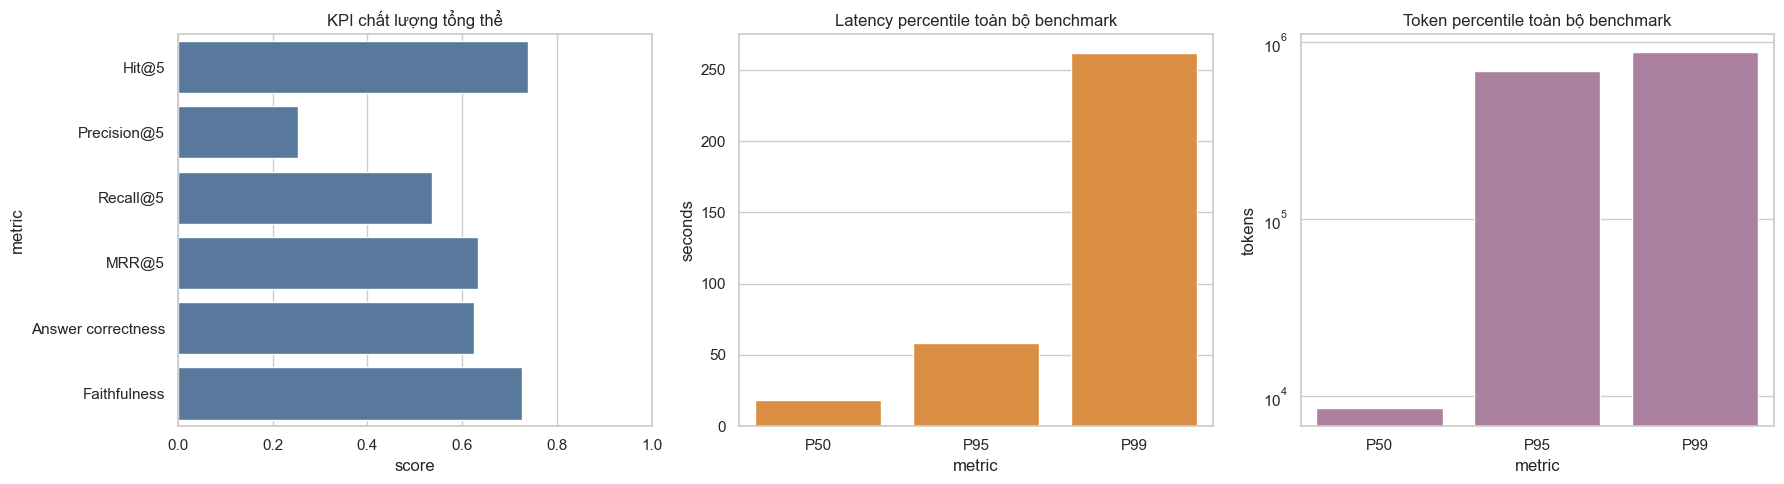

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = pd.DataFrame({
    "metric": ["Hit@5", "Precision@5", "Recall@5", "MRR@5", "Answer correctness", "Faithfulness"],
    "score": [
        df["hit@5"].mean(), df["precision@5"].mean(), df["recall@5"].mean(), df["mrr@5"].mean(),
        df["ragas_answer_correctness"].mean(), df["ragas_faithfulness"].mean(),
    ],
})
sns.barplot(data=metrics, y="metric", x="score", ax=axes[0], color="#4C78A8")
axes[0].set_title("KPI chất lượng tổng thể"); axes[0].set_xlim(0, 1)

latency_stats = pd.DataFrame({
    "metric": ["P50", "P95", "P99"],
    "seconds": [df["latency_s"].median(), df["latency_s"].quantile(.95), df["latency_s"].quantile(.99)],
})
sns.barplot(data=latency_stats, x="metric", y="seconds", ax=axes[1], color="#F28E2B")
axes[1].set_title("Latency percentile toàn bộ benchmark")

token_stats = pd.DataFrame({
    "metric": ["P50", "P95", "P99"],
    "tokens": [df["total_tokens"].median(), df["total_tokens"].quantile(.95), df["total_tokens"].quantile(.99)],
})
sns.barplot(data=token_stats, x="metric", y="tokens", ax=axes[2], color="#B279A2")
axes[2].set_yscale("log")
axes[2].set_title("Token percentile toàn bộ benchmark")

plt.tight_layout()
plt.show()


### Insight tổng quan

- Benchmark nhóm đạt mức retrieval tương đối ổn ở Hit@5, nhưng answer correctness vẫn thấp hơn retrieval, cho thấy lỗi không chỉ nằm ở việc tìm đúng tài liệu mà còn ở tổng hợp, grounding và hậu xử lý.
- P95 latency quan trọng hơn average latency khi đánh giá trải nghiệm người dùng; một số loại câu như `Multi-hop`, `Aggregation`, `Comparison` và `Post-processing heavy` thường tạo đuôi latency dài.
- Token usage có phân phối lệch mạnh, vì vậy nên đọc median/P95/P99 thay vì chỉ dùng trung bình.
- Từ đây trở xuống, EDA chỉ xem kết quả như một benchmark chung của nhóm và tách theo loại câu hỏi, route, partial hoặc từng câu cần audit.


## 3. Phân phối latency và token: tìm tail bottleneck

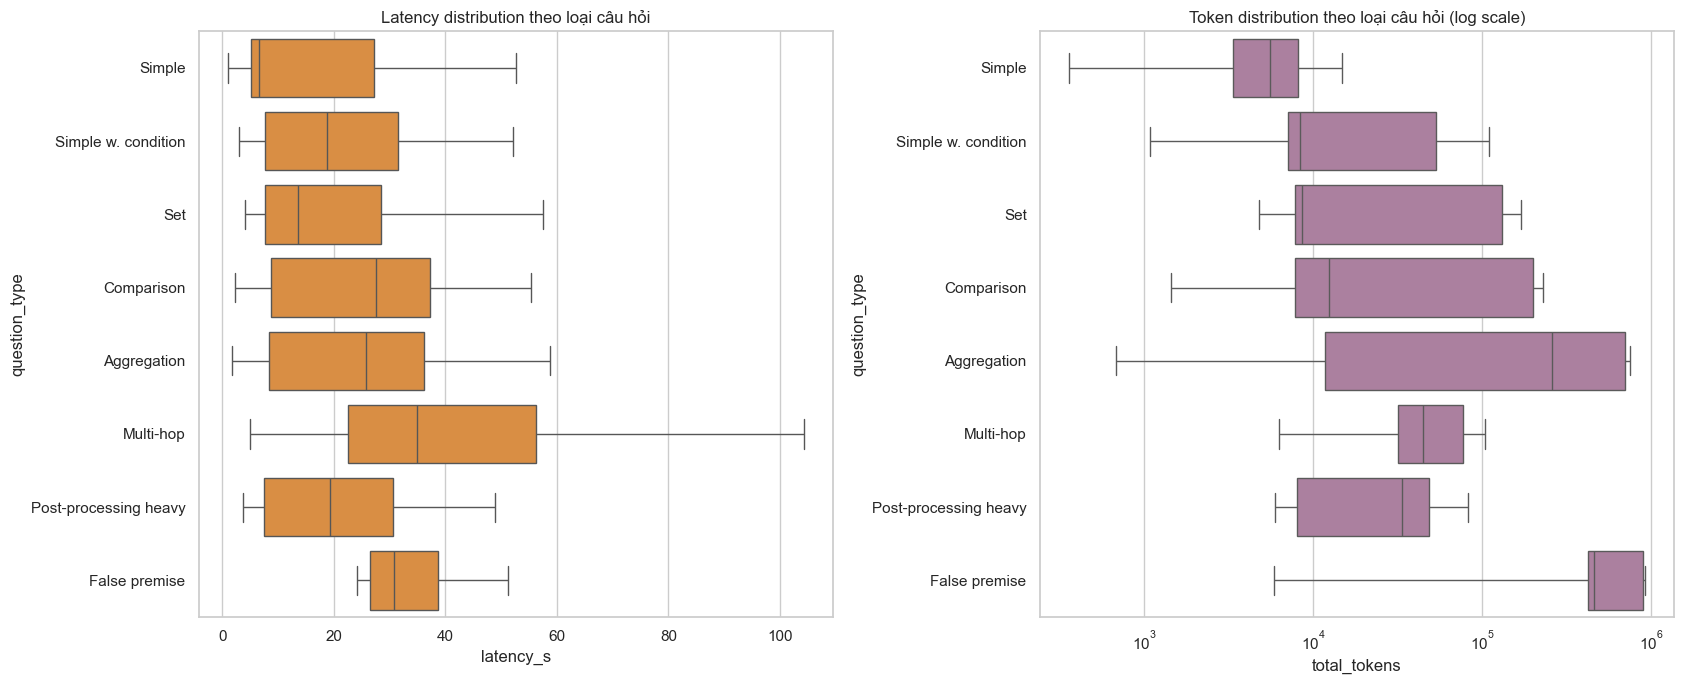

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.boxplot(data=df, x="latency_s", y="question_type", order=QUESTION_TYPE_ORDER, showfliers=False, ax=axes[0], color="#F28E2B")
axes[0].set_title("Latency distribution theo loại câu hỏi")
sns.boxplot(data=df, x="total_tokens", y="question_type", order=QUESTION_TYPE_ORDER, showfliers=False, ax=axes[1], color="#B279A2")
axes[1].set_xscale("log")
axes[1].set_title("Token distribution theo loại câu hỏi (log scale)")
plt.tight_layout()
plt.show()


In [7]:
tail = df.groupby("question_type", observed=False).agg(
    n=("qid", "size"),
    p50_latency=("latency_s", "median"),
    p95_latency=("latency_s", lambda s: s.quantile(.95)),
    p99_latency=("latency_s", lambda s: s.quantile(.99)),
    max_latency=("latency_s", "max"),
    p50_tokens=("total_tokens", "median"),
    p95_tokens=("total_tokens", lambda s: s.quantile(.95)),
    token_latency_corr=("total_tokens", lambda s: s.corr(df.loc[s.index, "latency_s"])),
).reindex(QUESTION_TYPE_ORDER)
tail["p95_over_p50"] = tail["p95_latency"] / tail["p50_latency"]
display(tail.round(2))


,n,p50_latency,p95_latency,p99_latency,max_latency,p50_tokens,p95_tokens,token_latency_corr,p95_over_p50
question_type,,,,,,,,,
Simple,416,6.58,41.93,48.29,52.57,5548.5,38956.00,0.25,6.37
Simple w. condition,100,18.69,42.28,52.28,69.68,8420.0,555364.55,0.27,2.26
Set,88,13.54,118.18,164.11,166.74,8624.5,615447.35,0.04,8.73
Comparison,75,27.55,93.58,181.87,344.57,12451.0,674059.10,-0.02,3.40
Aggregation,40,25.67,44.07,54.47,58.67,259318.0,742035.85,0.63,1.72
Multi-hop,146,34.99,264.36,330.63,349.41,44644.5,772619.00,-0.12,7.56
Post-processing heavy,113,19.26,41.62,115.96,167.73,33408.0,842886.20,0.54,2.16
False premise,27,30.82,49.77,123.45,148.82,458529.0,919992.70,0.41,1.61


### Bottleneck về hiệu năng

1. **Tail latency của câu phức tạp**: các nhóm `Multi-hop`, `Aggregation`, `Comparison` hoặc `Post-processing heavy` có thể kéo P95/P99 lên cao dù average nhìn vẫn ổn.
2. **Token telemetry có đuôi rất dài**: token trung bình dễ bị kéo lệch bởi một số câu hoặc pipeline nhiều bước. Khả năng gồm:
   - Token đang cộng cả context/chunk qua nhiều bước hoặc cộng lặp.
   - Cache/batch/provider usage được ghi nhận khác schema.
   - Trường `total_tokens` không cùng định nghĩa giữa các pipeline.
3. Trước khi tối ưu chi phí từ con số token tổng hợp, cần **chuẩn hóa cách đo token** và log token theo từng LLM call.


## 4. Retrieval có dẫn đến câu trả lời đúng không?

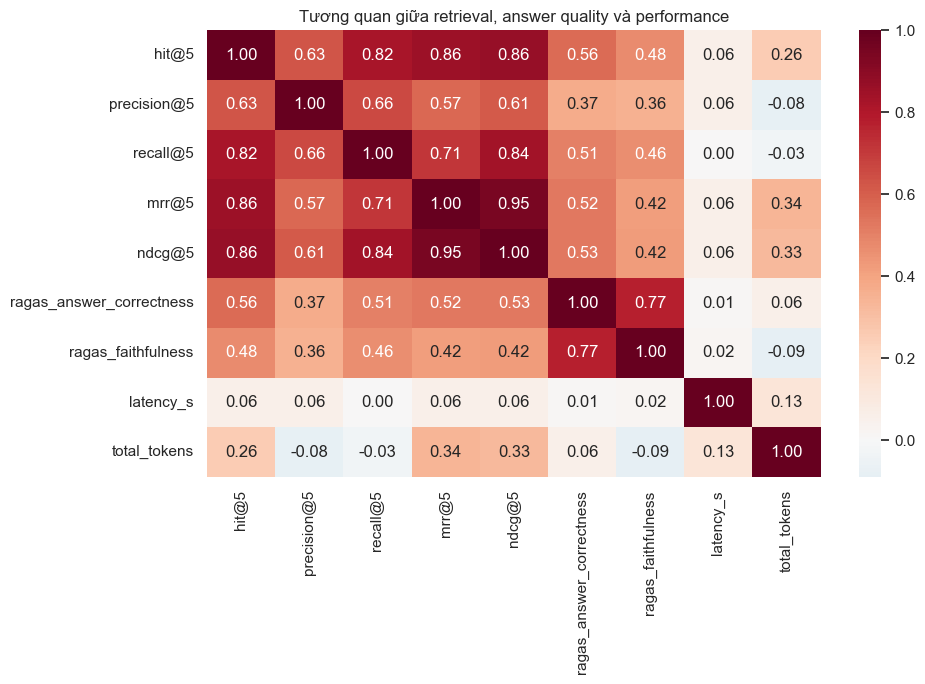

In [8]:
corr_cols = ["hit@5", "precision@5", "recall@5", "mrr@5", "ndcg@5",
             "ragas_answer_correctness", "ragas_faithfulness", "latency_s", "total_tokens"]
corr = df[corr_cols].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0)
plt.title("Tương quan giữa retrieval, answer quality và performance")
plt.tight_layout()
plt.show()

In [9]:
retrieval_impact = df.assign(hit_group=np.where(df["hit@5"] >= 1, "Hit@5 = 1", "Hit@5 < 1")).groupby("hit_group").agg(
    questions=("qid", "size"),
    answer_correctness=("ragas_answer_correctness", "mean"),
    faithfulness=("ragas_faithfulness", "mean"),
    answer_relevancy=("ragas_answer_relevancy", "mean"),
    latency_s=("latency_s", "mean"),
)
display(retrieval_impact.round(3))

failure_quadrants = pd.crosstab(
    np.where(df["hit@5"] >= 1, "retrieval_hit", "retrieval_miss"),
    np.where(df["ragas_answer_correctness"] >= .7, "answer_good", "answer_weak"),
    margins=True,
)
display(failure_quadrants)

,questions,answer_correctness,faithfulness,answer_relevancy,latency_s
hit_group,,,,,
Hit@5 < 1,262,0.213,0.417,0.334,23.021
Hit@5 = 1,743,0.769,0.835,0.895,28.217


col_0,answer_good,answer_weak,All
row_0,,,
retrieval_hit,547,196,743
retrieval_miss,46,216,262
All,593,412,1005


### Phân rã nguyên nhân lỗi

- **Retrieval miss + answer weak:** ưu tiên sửa index/chunking/query rewrite/reranking.
- **Retrieval hit + answer weak:** context đã có nhưng generation hoặc post-processing chưa khai thác đúng; cần kiểm tra prompt, context ordering, trích dẫn và bước tổng hợp.
- **Retrieval miss + answer good:** có thể metric relevance chưa phản ánh đủ tài liệu tương đương hoặc model dựa vào kiến thức sẵn có. Đây là dấu hiệu cần audit evaluator.
- Tương quan giữa Hit@5 và answer correctness giúp định lượng retrieval là một driver lớn, nhưng không phải driver duy nhất.

## 5. Loại câu hỏi, route và partial response


In [10]:
question_type_summary = df.groupby("question_type", observed=False).agg(
    n=("qid", "size"),
    hit5=("hit@5", "mean"),
    recall5=("recall@5", "mean"),
    correctness=("ragas_answer_correctness", "mean"),
    latency_s=("latency_s", "mean"),
    tokens=("total_tokens", "mean"),
    partial_rate=("partial", "mean"),
).reindex(QUESTION_TYPE_ORDER).sort_values("correctness")
display(question_type_summary.style.format({
    "hit5": "{:.3f}", "recall5": "{:.3f}", "correctness": "{:.3f}", "latency_s": "{:.2f}",
    "tokens": "{:,.1f}", "partial_rate": "{:.1%}"
}))


,n,hit5,recall5,correctness,latency_s,tokens,partial_rate
question_type,,,,,,,
Simple w. condition,100,0.590,0.390,0.501,20.79,"83,617.4",9.0%
False premise,27,0.815,0.407,0.511,34.52,"564,970.1",18.5%
Comparison,75,0.640,0.419,0.547,32.49,"152,101.0",16.0%
Simple,416,0.683,0.571,0.560,14.67,"22,259.8",8.7%
Aggregation,40,0.975,0.597,0.630,25.05,"324,765.3",7.5%
Set,88,0.750,0.500,0.728,26.06,"119,542.5",3.4%
Post-processing heavy,113,0.761,0.476,0.733,22.50,"154,005.5",11.5%
Multi-hop,146,0.952,0.674,0.803,65.81,"129,811.7",24.7%


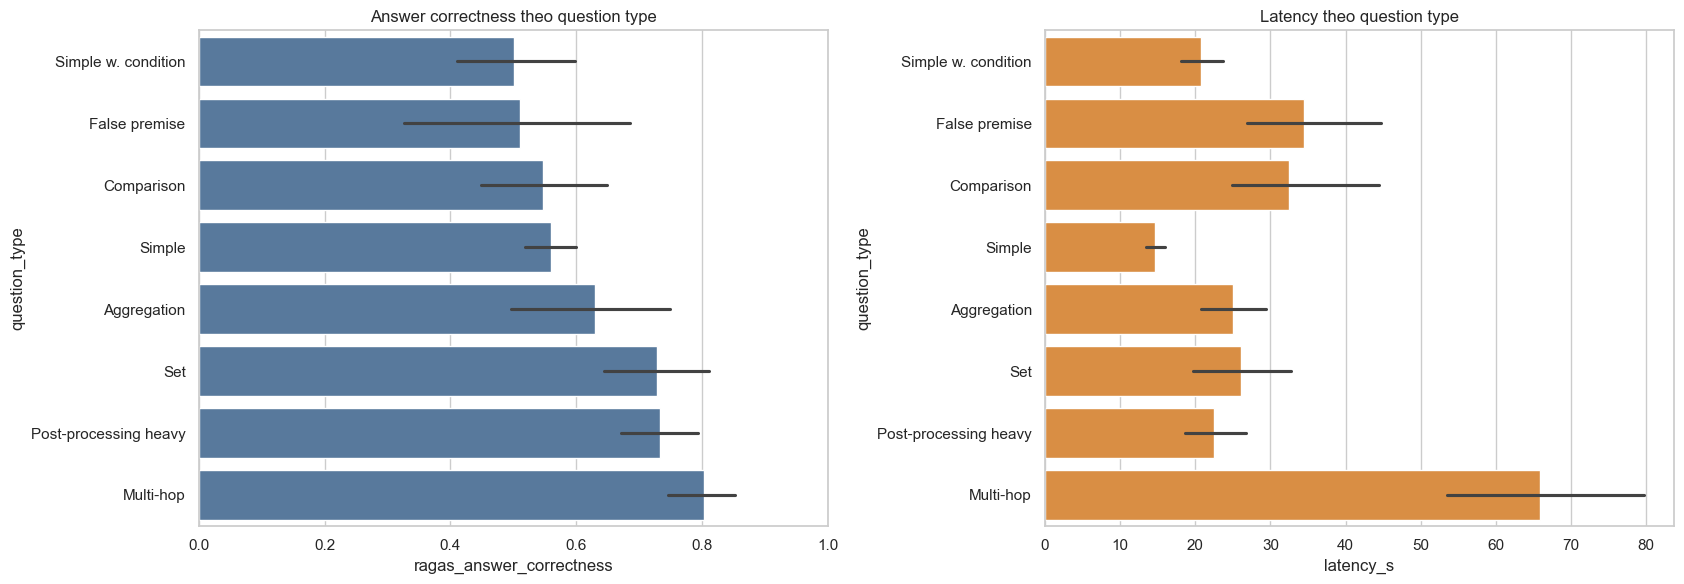

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
order = question_type_summary.index.tolist()
sns.barplot(data=df, y="question_type", x="ragas_answer_correctness", order=order, ax=axes[0], color="#4C78A8")
axes[0].set_title("Answer correctness theo question type"); axes[0].set_xlim(0, 1)
sns.barplot(data=df, y="question_type", x="latency_s", order=order, ax=axes[1], color="#F28E2B")
axes[1].set_title("Latency theo question type")
plt.tight_layout()
plt.show()


In [12]:
route_summary = df.groupby(["question_type", "route", "partial"], observed=False).agg(
    n=("qid", "size"),
    correctness=("ragas_answer_correctness", "mean"),
    hit5=("hit@5", "mean"),
    latency_s=("latency_s", "mean"),
    tokens=("total_tokens", "mean"),
).reset_index().sort_values(["question_type", "route", "partial"])
display(route_summary.style.format({
    "correctness": "{:.3f}", "hit5": "{:.3f}", "latency_s": "{:.2f}", "tokens": "{:,.1f}"
}))


,question_type,route,partial,n,correctness,hit5,latency_s,tokens
0,Simple,complex,False,5,1.000,1.000,19.56,"51,890.8"
1,Simple,complex,True,0,nan,nan,nan,nan
2,Simple,simple,False,375,0.591,0.709,14.67,"23,210.0"
3,Simple,simple,True,36,0.169,0.361,14.03,"8,246.3"
4,Simple w. condition,complex,False,2,1.000,0.500,19.12,"27,164.0"
5,Simple w. condition,complex,True,1,1.000,1.000,18.30,"51,956.0"
6,Simple w. condition,simple,False,89,0.518,0.629,19.95,"91,902.3"
7,Simple w. condition,simple,True,8,0.125,0.125,30.84,"9,519.4"
8,Set,complex,False,6,0.895,1.000,95.02,"41,830.7"
9,Set,complex,True,1,0.420,1.000,166.74,"55,619.0"


### Insight theo loại câu hỏi và routing

- `question_type` là lát cắt chính để tách lỗi do loại câu khỏi lỗi do corpus/index/pipeline.
- Các nhóm **Aggregation**, **Comparison**, **Multi-hop** và **Post-processing heavy** nên được theo dõi riêng vì retrieval hit cao vẫn có thể thất bại ở bước tính toán/tổng hợp/hậu xử lý.
- Nhóm **Simple** và **Simple w. condition** là baseline tốt để kiểm tra retrieval và grounding cơ bản trước khi tối ưu câu phức tạp.
- Tỷ lệ `partial=True` là tín hiệu vận hành quan trọng; cần phân biệt partial do budget, timeout, loop cap hay lỗi downstream.


## 6. Danh sách câu hỏi cần audit ưu tiên

In [13]:
audit = df.assign(
    priority_score=(
        (1 - df["ragas_answer_correctness"].fillna(0)) * 0.45
        + (1 - df["hit@5"].fillna(0)) * 0.30
        + df["latency_s"].rank(pct=True).fillna(0) * 0.15
        + df["partial"].astype(float) * 0.10
    )
).sort_values("priority_score", ascending=False)

cols = ["qid", "question_type", "route", "partial", "hit@5", "recall@5",
        "ragas_answer_correctness", "latency_s", "total_tokens", "question"]
display(audit[cols].head(25).style.format({
    "hit@5": "{:.2f}", "recall@5": "{:.2f}", "ragas_answer_correctness": "{:.2f}",
    "latency_s": "{:.2f}", "total_tokens": "{:,.0f}"
}))


,qid,question_type,route,partial,hit@5,recall@5,ragas_answer_correctness,latency_s,total_tokens,question
338,DOC003_Q04,Comparison,simple,True,0.00,0.00,0.00,43.18,"12,451",Cần lưu ý điều kiện hoặc phạm vi nào khi dùng tài liệu để trả lời về giá hoặc điều kiện?
373,DOC010_Q04,Comparison,simple,True,0.00,0.00,0.00,40.97,"8,610","Nếu người dùng chỉ hỏi “nên chọn/ưu tiên nội dung nào” mà không nói rõ họ quan tâm gói/quyền lợi/thông số, giá hoặc điều kiện hay lựa chọn phù hợp nhu cầu, nên xử lý thế nào?"
22,2026_293_159_2026_NĐ-CP_Q03,Simple w. condition,simple,True,0.00,0.00,0.00,38.30,"6,128",Quy định tại Điều 3 của tài liệu nêu nội dung chính nào cần chú ý khi đánh giá RAG?
37,2026_294_167_2026_NĐ-CP_Q03,Simple w. condition,simple,True,0.00,0.00,0.00,38.10,"6,127",Quy định tại Điều 3 của tài liệu nêu nội dung chính nào cần chú ý khi đánh giá RAG?
368,DOC009_Q04,Comparison,simple,True,0.00,0.00,0.00,36.42,"12,457",Cần lưu ý điều kiện hoặc phạm vi nào khi dùng tài liệu để trả lời về giá hoặc điều kiện?
347,DOC005_Q03,Simple,simple,True,0.00,0.00,0.00,36.38,"6,901","Khi tra cứu nhanh tài liệu này, nên chú ý những nhóm thông tin nào?"
348,DOC005_Q04,Comparison,simple,True,0.00,0.00,0.00,35.97,"6,639","Nếu người dùng chỉ hỏi “nên chọn/ưu tiên nội dung nào” mà không nói rõ họ quan tâm khái niệm công nghệ, yêu cầu triển khai hay rủi ro/quản trị, nên xử lý thế nào?"
356,DOC007_Q02,Simple,simple,True,0.00,0.00,0.00,35.89,"5,287","Trong ngữ cảnh tài liệu này, nhóm nội dung “bối cảnh xã hội” nên được hiểu là gì?"
32,2026_293_66.17_2026_NQ-CP_Q03,Simple w. condition,simple,True,0.00,0.00,0.00,35.62,"6,127",Quy định tại Điều 3 của tài liệu nêu nội dung chính nào cần chú ý khi đánh giá RAG?
57,2026_294_185_2026_NĐ-CP_Q03,Simple w. condition,simple,True,0.00,0.00,0.00,35.43,"13,117",Quy định tại Điều 3 của tài liệu nêu nội dung chính nào cần chú ý khi đánh giá RAG?


In [14]:
outliers = df.loc[df["latency_s"] >= df["latency_s"].quantile(.99), cols].sort_values("latency_s", ascending=False)
display(Markdown(f"**Top 1% latency gồm {len(outliers)} câu:**"))
display(outliers.head(20).style.format({"latency_s": "{:.2f}", "total_tokens": "{:,.0f}"}))

**Top 1% latency gồm 11 câu:**

,qid,question_type,route,partial,hit@5,recall@5,ragas_answer_correctness,latency_s,total_tokens,question
389,DOC013_Q05,Multi-hop,complex,True,1.000000,0.333333,1.000000,349.41,"78,328","Để trả lời một câu hỏi tổng hợp về VITRANSS 3 - Chiến lược phát triển giao thông vận tải bền vững, cần kết nối những lớp thông tin nào trong tài liệu?"
328,DOC001_Q04,Comparison,complex,True,0.000000,0.000000,0.500000,344.57,"70,733",Cần lưu ý điều kiện hoặc phạm vi nào khi dùng tài liệu để trả lời về giá hoặc điều kiện?
329,DOC001_Q05,Multi-hop,complex,True,1.000000,1.000000,1.000000,334.68,"73,665","Để trả lời một câu hỏi tổng hợp về VinFast VF 3 brochure, cần kết nối những lớp thông tin nào trong tài liệu?"
374,DOC010_Q05,Multi-hop,complex,True,1.000000,0.500000,1.000000,325.68,"35,268","Để trả lời một câu hỏi tổng hợp về VinFast VF e34 brochure, cần kết nối những lớp thông tin nào trong tài liệu?"
339,DOC003_Q05,Multi-hop,complex,True,1.000000,1.000000,1.000000,318.07,"32,757","Để trả lời một câu hỏi tổng hợp về VinFast VF 5 brochure, cần kết nối những lớp thông tin nào trong tài liệu?"
404,DOC016_Q05,Multi-hop,complex,True,1.000000,1.000000,0.000000,301.94,"41,121","Để trả lời một câu hỏi tổng hợp về Báo cáo chuyển đổi số quốc gia 2023, cần kết nối những lớp thông tin nào trong tài liệu?"
369,DOC009_Q05,Multi-hop,complex,True,1.000000,0.500000,0.000000,298.80,"53,198","Để trả lời một câu hỏi tổng hợp về VinFast VF 9 brochure, cần kết nối những lớp thông tin nào trong tài liệu?"
34,2026_293_66.17_2026_NQ-CP_Q05,Multi-hop,complex,False,1.000000,1.000000,1.000000,296.14,"41,796","Khi một thủ tục/điều kiện kinh doanh đã được cắt giảm hoặc phân quyền nhưng hồ sơ đã nộp trước ngày văn bản có hiệu lực, hệ thống RAG cần xử lý câu trả lời theo logic nào?"
364,DOC008_Q05,Multi-hop,complex,False,0.000000,0.000000,0.000000,264.67,"32,291","Để trả lời một câu hỏi tổng hợp về Hướng dẫn sử dụng thiết bị y tế, cần kết nối những lớp thông tin nào trong tài liệu?"
414,DOC018_Q05,Multi-hop,complex,True,1.000000,0.400000,1.000000,263.44,"47,845","Để trả lời một câu hỏi tổng hợp về Thông tư 02/2024 về lao động nước ngoài, cần kết nối những lớp thông tin nào trong tài liệu?"


## 7. Kết luận, nguyên nhân và hướng cải thiện

### Chẩn đoán chính

| Mức ưu tiên | Bottleneck | Dấu hiệu trong log | Nguyên nhân khả dĩ |
|---|---|---|---|
| P0 | Chất lượng nhóm câu yếu còn thấp | Retrieval và answer correctness cùng thấp ở một số cụm câu | Corpus/index mismatch, chunking, query rewrite hoặc relevance judge |
| P0 | Telemetry token chưa đồng nhất | Token có đuôi rất dài nhưng tương quan latency không ổn định | Khác định nghĩa token, cộng lặp usage hoặc log nhiều bước không chuẩn |
| P1 | Câu phức tạp cần xử lý riêng | Aggregation/Comparison/Multi-hop/Post-processing heavy có cơ chế lỗi khác nhau | Router chưa nhận diện intent, thiếu decomposition/calculator/verifier |
| P1 | Retrieval hit nhưng answer vẫn yếu | Có nhiều câu hit nhưng correctness dưới ngưỡng | Context ordering, prompt tổng hợp, post-processing hoặc citation grounding |
| P1 | Tail latency cao | P95/P99 cách xa median ở một số nhóm câu hỏi | Nhiều vòng lặp, context lớn, retry, tool/LLM call nối tiếp |
| P2 | Partial response | Tập trung ở một số nhóm câu và pipeline | Timeout, iteration cap, token budget hoặc lỗi orchestration |

### Hướng cải thiện đề xuất

1. **Chuẩn hóa benchmark và telemetry trước**
   - Một schema chung cho `prompt_tokens`, `completion_tokens`, `total_tokens`, `llm_calls`, latency từng stage.
   - Ghi rõ evaluator backend/relevance mode theo từng câu.
   - Thêm `trace_id`, thời gian retrieval/rerank/generation/post-processing.

2. **Tập trung sửa retrieval cho các nhóm câu có correctness thấp**
   - Audit 25 câu ưu tiên ở trên, phân loại lỗi: missing document, bad chunk, bad query, bad rank.
   - Thử hybrid retrieval + reranker; đo Recall@20 trước rerank và NDCG@5 sau rerank.
   - Điều chỉnh chunk size/overlap theo loại tài liệu thay vì dùng một cấu hình chung.

3. **Cải thiện router cho 8 loại câu hỏi CRAG**
   - `Simple`: ưu tiên grounding ngắn, ít context.
   - `Simple w. condition`: đảm bảo điều kiện được giữ trong query rewrite.
   - `Set`: sinh câu trả lời dạng danh sách, kiểm tra thiếu/thừa thực thể.
   - `Comparison`: truy xuất đủ cả hai vế và buộc mô hình so sánh theo tiêu chí.
   - `Aggregation`: thêm bước tính toán/count/sum sau retrieval.
   - `Multi-hop`: decomposition thành sub-question và hợp nhất bằng verifier.
   - `Post-processing heavy`: thêm parser/calculator/verifier thay vì để LLM tự nhẩm.
   - `False premise`: thêm bước phát hiện tiền đề sai, cho phép trả lời từ chối có căn cứ.

4. **Giảm tail latency**
   - Cache retrieval và judge theo `(qid, query, expected_doc)`.
   - Đặt budget context theo loại câu hỏi.
   - Log số vòng lặp/router decisions để phát hiện câu bị loop.

5. **Thiết lập baseline lần sau**
   - Giữ nguyên 1.005 câu và cùng evaluator.
   - Báo cáo chính theo 8 loại câu hỏi, không so sánh theo người/source.
   - Theo dõi thêm `cost/question`, `retrieval_ms`, `generation_ms`, `judge_ms`, `partial_reason`.


In [15]:
# Bảng baseline gọn để dùng làm mốc cho lần cải thiện tiếp theo
baseline_overall = overall_summary.rename(columns={
    "questions": "n",
    "answer_correctness": "correctness",
    "avg_latency_s": "latency_s",
    "avg_tokens": "tokens",
})[["n", "hit5", "recall5", "correctness", "latency_s", "tokens", "partial_rate"]]

baseline_by_type = question_type_summary.rename(columns={"correctness": "correctness"})[
    ["n", "hit5", "recall5", "correctness", "latency_s", "tokens", "partial_rate"]
].copy()
baseline_by_type = baseline_by_type[["n", "hit5", "recall5", "correctness", "latency_s", "tokens", "partial_rate"]]

baseline = pd.concat([baseline_overall, baseline_by_type])
display(baseline.style.format({
    "hit5": "{:.3f}", "recall5": "{:.3f}", "correctness": "{:.3f}",
    "latency_s": "{:.2f}", "tokens": "{:,.1f}", "partial_rate": "{:.1%}",
}, na_rep="-"))


,n,hit5,recall5,correctness,latency_s,tokens,partial_rate
Team benchmark,1005,0.739,0.536,0.624,26.86,"103,630.9",11.6%
Simple w. condition,100,0.590,0.390,0.501,20.79,"83,617.4",9.0%
False premise,27,0.815,0.407,0.511,34.52,"564,970.1",18.5%
Comparison,75,0.640,0.419,0.547,32.49,"152,101.0",16.0%
Simple,416,0.683,0.571,0.560,14.67,"22,259.8",8.7%
Aggregation,40,0.975,0.597,0.630,25.05,"324,765.3",7.5%
Set,88,0.750,0.500,0.728,26.06,"119,542.5",3.4%
Post-processing heavy,113,0.761,0.476,0.733,22.50,"154,005.5",11.5%
Multi-hop,146,0.952,0.674,0.803,65.81,"129,811.7",24.7%
